# One-Object Fourier Motion Benchmark Analysis

This notebook analyzes the one-object synthetic benchmark comparing:

1. Phase / Prony detector
2. 3D Fourier plane-scoring detector

The benchmark varies object shape, speed, direction, noise level, frame count, and random seed.

Main metrics:

- Endpoint error
- Speed error
- Angular error
- Success at thresholds 0.1, 0.2, 0.5 px/frame
- Runtime
- Score-map diagnostics: top score, second score, peak ratio, peak margin

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["figure.dpi"] = 140

ROOT = Path.cwd().parent
RESULT_DIR = ROOT / "results" / "one_object"
print(RESULT_DIR)
csv_files = sorted(RESULT_DIR.glob("one_object_*.csv"))

csv_files

/Users/mforlive/Documents/Computer_Vision_with_DL/final_project/results/one_object


[PosixPath('/Users/mforlive/Documents/Computer_Vision_with_DL/final_project/results/one_object/one_object_disk.csv'),
 PosixPath('/Users/mforlive/Documents/Computer_Vision_with_DL/final_project/results/one_object/one_object_gaussian.csv'),
 PosixPath('/Users/mforlive/Documents/Computer_Vision_with_DL/final_project/results/one_object/one_object_square.csv')]

In [31]:
# Load all available one-object CSVs.

dfs = []

for f in csv_files:
    print("loading", f)
    df_i = pd.read_csv(f)
    df_i["source_file"] = f.name
    dfs.append(df_i)

df = pd.concat(dfs, ignore_index=True)

print("shape:", df.shape)
df.head()

loading /Users/mforlive/Documents/Computer_Vision_with_DL/final_project/results/one_object/one_object_disk.csv
loading /Users/mforlive/Documents/Computer_Vision_with_DL/final_project/results/one_object/one_object_gaussian.csv
loading /Users/mforlive/Documents/Computer_Vision_with_DL/final_project/results/one_object/one_object_square.csv
shape: (11520, 28)


,status,error_message,method,shape,size,T,H,W,noise_std,seed,...,angular_error_deg,success_at_0.1,success_at_0.2,success_at_0.5,runtime_sec,top1_score,top2_score,peak_ratio,peak_margin,source_file
0,ok,NaN,phase,disk,5.0,16.0,128.0,128.0,0.0,4.0,...,0.0,True,True,True,42.978240,42619.271917,41873.21403,1.017817,746.057887,one_object_disk.csv
1,ok,NaN,phase,disk,5.0,16.0,128.0,128.0,0.0,3.0,...,0.0,True,True,True,42.985081,42619.271917,41873.21403,1.017817,746.057887,one_object_disk.csv
2,ok,NaN,phase,disk,5.0,16.0,128.0,128.0,0.0,2.0,...,0.0,True,True,True,43.253691,42619.271917,41873.21403,1.017817,746.057887,one_object_disk.csv
3,ok,NaN,phase,disk,5.0,16.0,128.0,128.0,0.0,0.0,...,0.0,True,True,True,43.289572,42619.271917,41873.21403,1.017817,746.057887,one_object_disk.csv
4,ok,NaN,phase,disk,5.0,16.0,128.0,128.0,0.0,1.0,...,0.0,True,True,True,43.404241,42619.271917,41873.21403,1.017817,746.057887,one_object_disk.csv


In [32]:
# Basic cleanup.

bool_cols = ["success_at_0.1", "success_at_0.2", "success_at_0.5"]

for c in bool_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).str.lower().map({
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }).astype(bool)

numeric_cols = [
    "size", "T", "H", "W", "noise_std", "seed", "speed", "direction_deg",
    "vx_gt", "vy_gt", "vx_hat", "vy_hat",
    "endpoint_error", "speed_error", "angular_error_deg",
    "runtime_sec", "top1_score", "top2_score", "peak_ratio", "peak_margin",
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df_ok = df[df["status"] == "ok"].copy()

print("all rows:", len(df))
print("ok rows:", len(df_ok))
print("failed rows:", len(df) - len(df_ok))

df["status"].value_counts(dropna=False)

all rows: 11520
ok rows: 11520
failed rows: 0


status
ok    11520
Name: count, dtype: int64

In [33]:
# Check coverage: did every method/shape combination finish?

coverage = (
    df.groupby(["shape", "method"])
    .size()
    .reset_index(name="n_rows")
    .sort_values(["shape", "method"])
)

coverage

,shape,method,n_rows
0,disk,phase,1920
1,disk,plane,1920
2,gaussian,phase,1920
3,gaussian,plane,1920
4,square,phase,1920
5,square,plane,1920


In [34]:
# High-level summary table.

summary = (
    df_ok.groupby("method")
    .agg(
        n=("endpoint_error", "count"),
        mean_epe=("endpoint_error", "mean"),
        median_epe=("endpoint_error", "median"),
        p90_epe=("endpoint_error", lambda x: np.percentile(x.dropna(), 90)),
        mean_speed_error=("speed_error", "mean"),
        median_angular_error=("angular_error_deg", "median"),
        success_0_1=("success_at_0.1", "mean"),
        success_0_2=("success_at_0.2", "mean"),
        success_0_5=("success_at_0.5", "mean"),
        mean_runtime=("runtime_sec", "mean"),
        median_runtime=("runtime_sec", "median"),
    )
    .reset_index()
)

summary

,method,n,mean_epe,median_epe,p90_epe,mean_speed_error,median_angular_error,success_0_1,success_0_2,success_0_5,mean_runtime,median_runtime
0,phase,5760,0.022899,0.018545,0.050000,0.019094,0.0,0.984896,1.000000,1.000000,50.989890,47.713798
1,plane,5760,0.309101,0.066667,1.112826,0.191354,0.0,0.648611,0.747222,0.827431,55.097945,46.764520


In [35]:
# Same summary, split by shape.

summary_by_shape = (
    df_ok.groupby(["shape", "method"])
    .agg(
        n=("endpoint_error", "count"),
        mean_epe=("endpoint_error", "mean"),
        median_epe=("endpoint_error", "median"),
        p90_epe=("endpoint_error", lambda x: np.percentile(x.dropna(), 90)),
        success_0_2=("success_at_0.2", "mean"),
        success_0_5=("success_at_0.5", "mean"),
        mean_runtime=("runtime_sec", "mean"),
    )
    .reset_index()
)

summary_by_shape

,shape,method,n,mean_epe,median_epe,p90_epe,success_0_2,success_0_5,mean_runtime
0,disk,phase,1920,0.017264,0.016667,0.033333,1.000000,1.000000,47.907692
1,disk,plane,1920,0.056840,0.033333,0.093165,0.979167,0.979688,40.277644
2,gaussian,phase,1920,0.025908,0.018545,0.066667,1.000000,1.000000,47.931440
3,gaussian,plane,1920,0.779850,0.432759,2.193171,0.304688,0.544792,60.293277
4,square,phase,1920,0.025525,0.020101,0.061438,1.000000,1.000000,57.130540
5,square,plane,1920,0.090613,0.037090,0.110347,0.957812,0.957812,64.722915


In [36]:
# Helper plotting function.

def grouped_lineplot(
    data,
    x,
    y,
    group="method",
    title=None,
    xlabel=None,
    ylabel=None,
    marker="o",
):
    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    for name, g in data.groupby(group):
        g = g.sort_values(x)
        ax.plot(g[x], g[y], marker=marker, label=name)

    ax.set_title(title or f"{y} vs {x}")
    ax.set_xlabel(xlabel or x)
    ax.set_ylabel(ylabel or y)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    return fig, ax

/var/folders/g2/g88jmmpn74j7j_hr4sgn9zjw0000gr/T/ipykernel_73106/26704399.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=methods, showfliers=False)


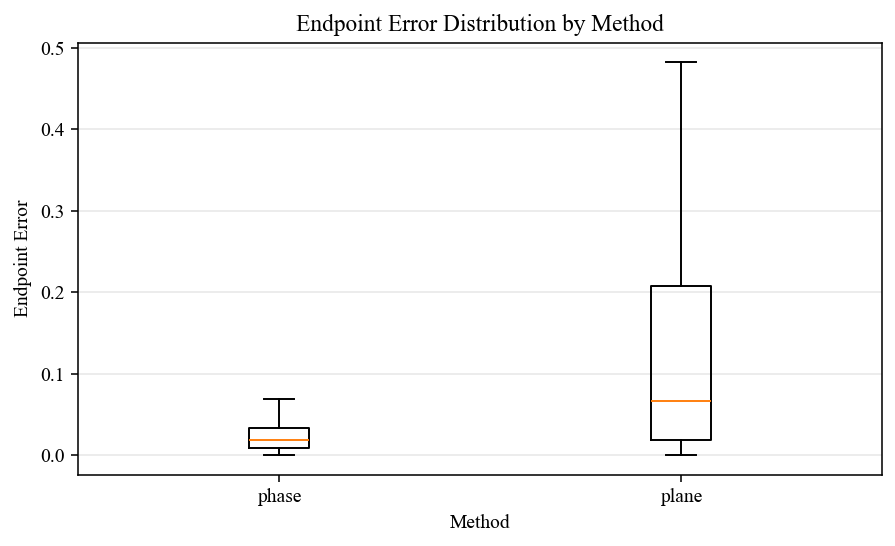

In [37]:
# Plot 1: Overall endpoint error distribution by method.

fig, ax = plt.subplots(figsize=(6.5, 4.0))

methods = sorted(df_ok["method"].dropna().unique())
values = [df_ok.loc[df_ok["method"] == m, "endpoint_error"].dropna().values for m in methods]

ax.boxplot(values, labels=methods, showfliers=False)
ax.set_title("Endpoint Error Distribution by Method")
ax.set_xlabel("Method")
ax.set_ylabel("Endpoint Error")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

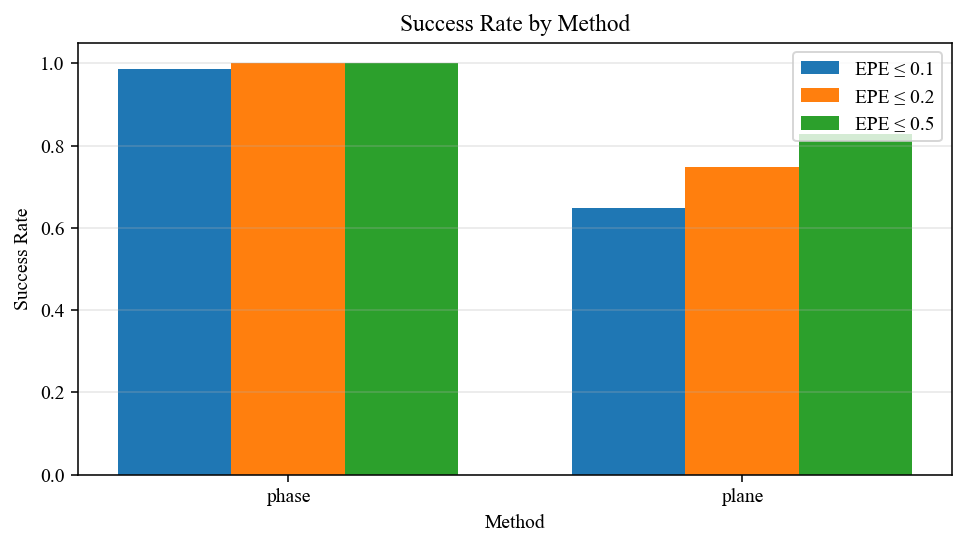

In [38]:
# Plot 2: Success rate by method and threshold.

success_long = []

for threshold_col in ["success_at_0.1", "success_at_0.2", "success_at_0.5"]:
    tmp = (
        df_ok.groupby("method")[threshold_col]
        .mean()
        .reset_index()
        .rename(columns={threshold_col: "success_rate"})
    )
    tmp["threshold"] = threshold_col.replace("success_at_", "")
    success_long.append(tmp)

success_long = pd.concat(success_long, ignore_index=True)

fig, ax = plt.subplots(figsize=(7.0, 4.0))

x = np.arange(len(methods))
width = 0.25

thresholds = ["0.1", "0.2", "0.5"]

for i, th in enumerate(thresholds):
    vals = []
    for m in methods:
        v = success_long[
            (success_long["method"] == m) &
            (success_long["threshold"] == th)
        ]["success_rate"].iloc[0]
        vals.append(v)

    ax.bar(x + (i - 1) * width, vals, width, label=f"EPE ≤ {th}")

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylim(0, 1.05)
ax.set_title("Success Rate by Method")
ax.set_xlabel("Method")
ax.set_ylabel("Success Rate")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

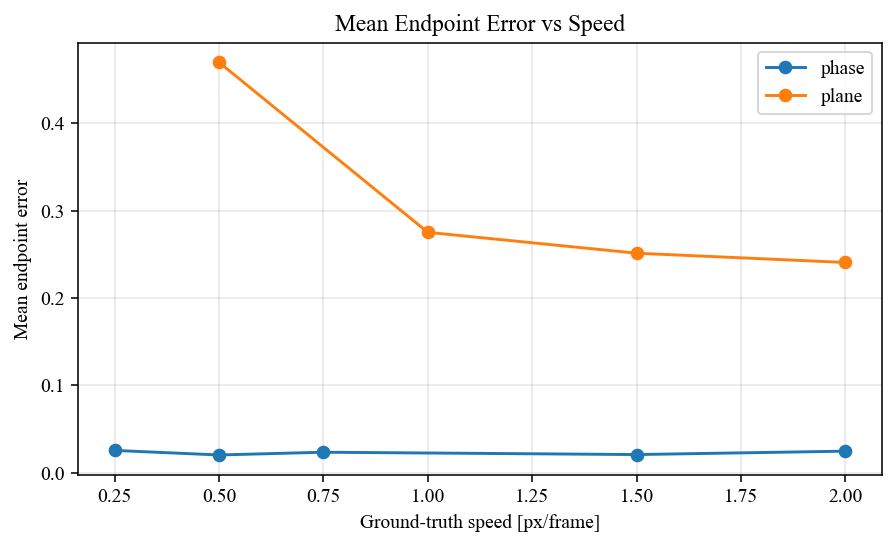

In [39]:
# Plot 3: Mean endpoint error vs speed.

speed_summary = (
    df_ok.groupby(["method", "speed"])
    .agg(
        mean_epe=("endpoint_error", "mean"),
        median_epe=("endpoint_error", "median"),
        success_0_2=("success_at_0.2", "mean"),
        success_0_5=("success_at_0.5", "mean"),
    )
    .reset_index()
)

grouped_lineplot(
    speed_summary,
    x="speed",
    y="mean_epe",
    title="Mean Endpoint Error vs Speed",
    xlabel="Ground-truth speed [px/frame]",
    ylabel="Mean endpoint error",
)
plt.show()

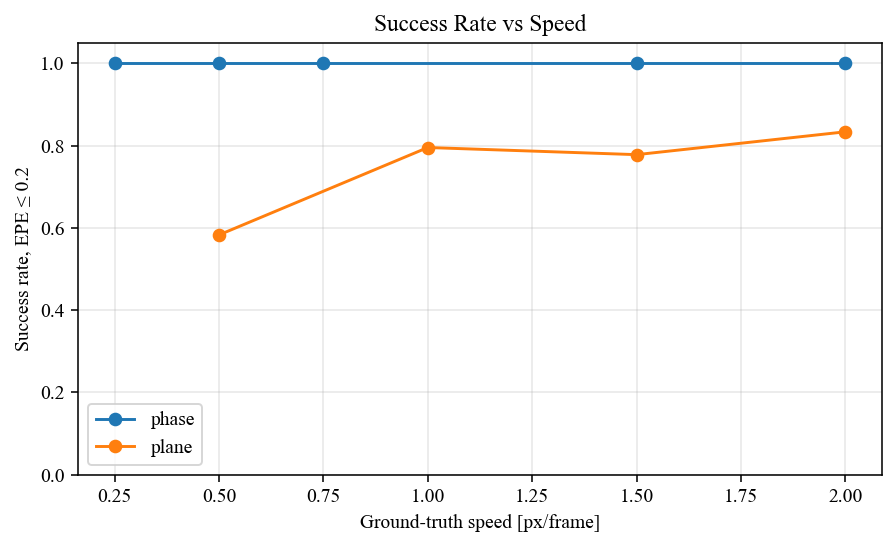

In [40]:
# Plot 4: Success rate vs speed.

grouped_lineplot(
    speed_summary,
    x="speed",
    y="success_0_2",
    title="Success Rate vs Speed",
    xlabel="Ground-truth speed [px/frame]",
    ylabel="Success rate, EPE ≤ 0.2",
)
plt.ylim(0, 1.05)
plt.show()

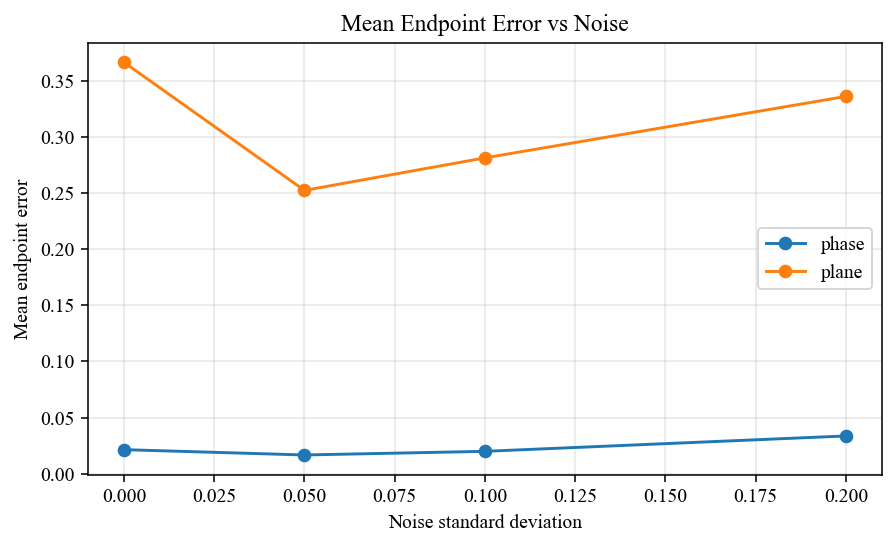

In [41]:
# Plot 5: Mean endpoint error vs noise.

noise_summary = (
    df_ok.groupby(["method", "noise_std"])
    .agg(
        mean_epe=("endpoint_error", "mean"),
        median_epe=("endpoint_error", "median"),
        success_0_2=("success_at_0.2", "mean"),
        success_0_5=("success_at_0.5", "mean"),
    )
    .reset_index()
)

grouped_lineplot(
    noise_summary,
    x="noise_std",
    y="mean_epe",
    title="Mean Endpoint Error vs Noise",
    xlabel="Noise standard deviation",
    ylabel="Mean endpoint error",
)
plt.show()

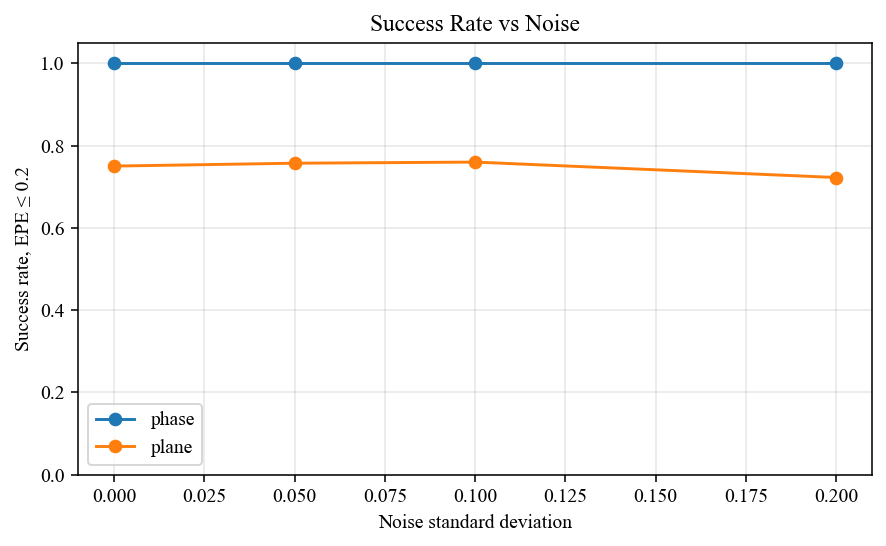

In [42]:
# Plot 6: Success rate vs noise.

grouped_lineplot(
    noise_summary,
    x="noise_std",
    y="success_0_2",
    title="Success Rate vs Noise",
    xlabel="Noise standard deviation",
    ylabel="Success rate, EPE ≤ 0.2",
)
plt.ylim(0, 1.05)
plt.show()

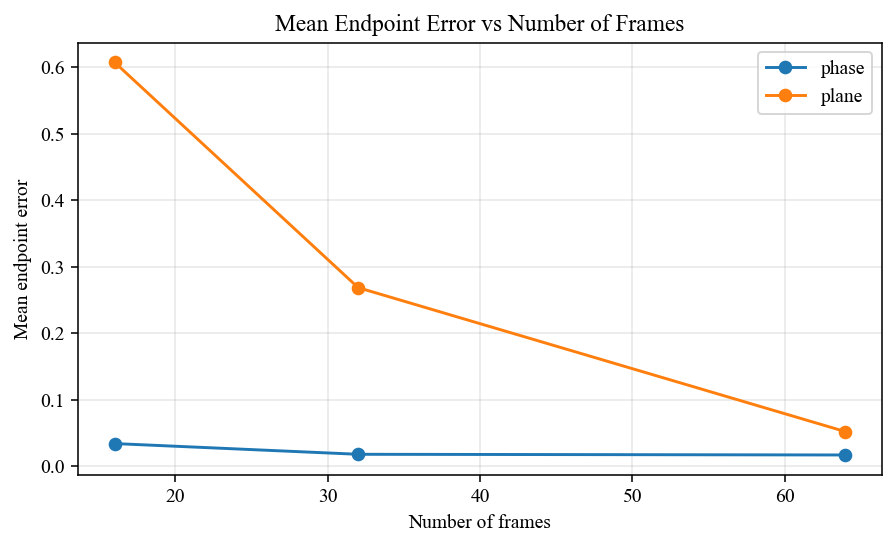

In [43]:
# Plot 7: Mean endpoint error vs number of frames.

T_summary = (
    df_ok.groupby(["method", "T"])
    .agg(
        mean_epe=("endpoint_error", "mean"),
        median_epe=("endpoint_error", "median"),
        success_0_2=("success_at_0.2", "mean"),
        success_0_5=("success_at_0.5", "mean"),
        mean_runtime=("runtime_sec", "mean"),
    )
    .reset_index()
)

grouped_lineplot(
    T_summary,
    x="T",
    y="mean_epe",
    title="Mean Endpoint Error vs Number of Frames",
    xlabel="Number of frames",
    ylabel="Mean endpoint error",
)
plt.show()

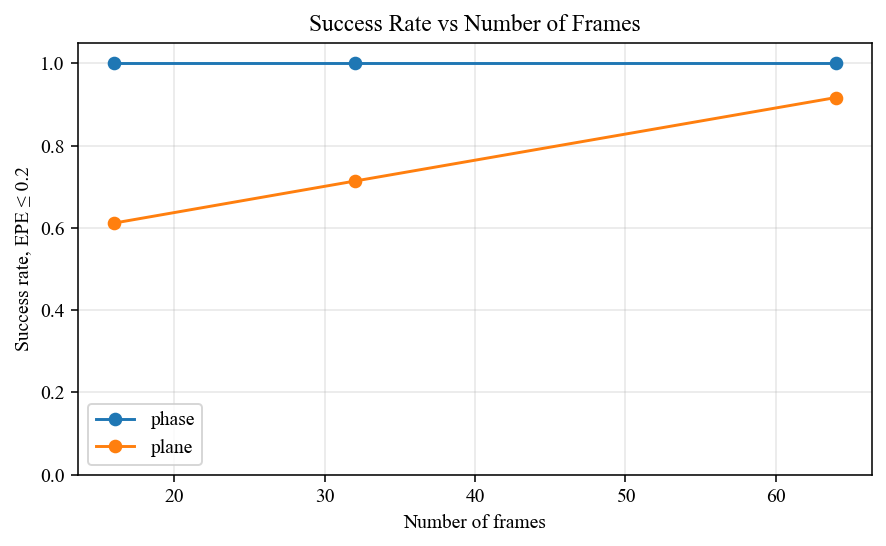

In [44]:
# Plot 8: Success rate vs number of frames.

grouped_lineplot(
    T_summary,
    x="T",
    y="success_0_2",
    title="Success Rate vs Number of Frames",
    xlabel="Number of frames",
    ylabel="Success rate, EPE ≤ 0.2",
)
plt.ylim(0, 1.05)
plt.show()

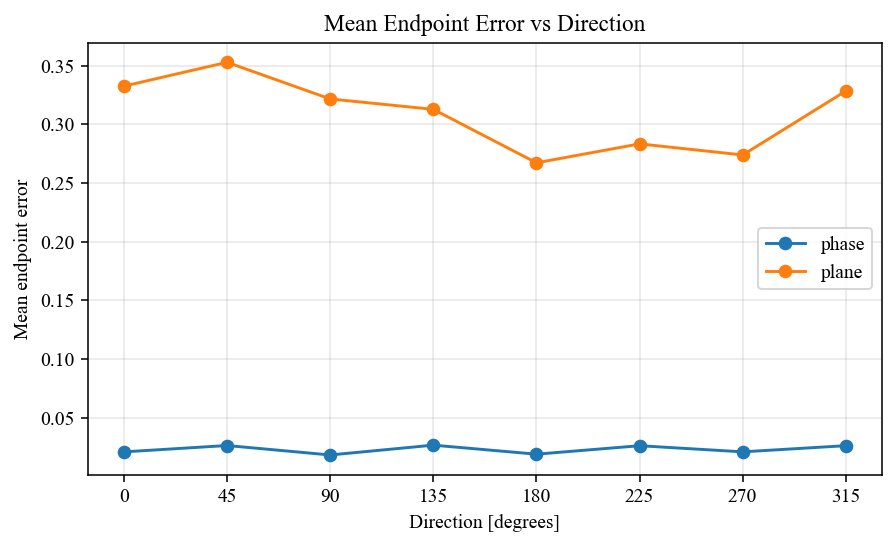

In [45]:
# Plot 9: Error by direction.

direction_summary = (
    df_ok.groupby(["method", "direction_deg"])
    .agg(
        mean_epe=("endpoint_error", "mean"),
        median_epe=("endpoint_error", "median"),
        success_0_2=("success_at_0.2", "mean"),
    )
    .reset_index()
)

grouped_lineplot(
    direction_summary,
    x="direction_deg",
    y="mean_epe",
    title="Mean Endpoint Error vs Direction",
    xlabel="Direction [degrees]",
    ylabel="Mean endpoint error",
)
plt.xticks(sorted(df_ok["direction_deg"].dropna().unique()))
plt.show()

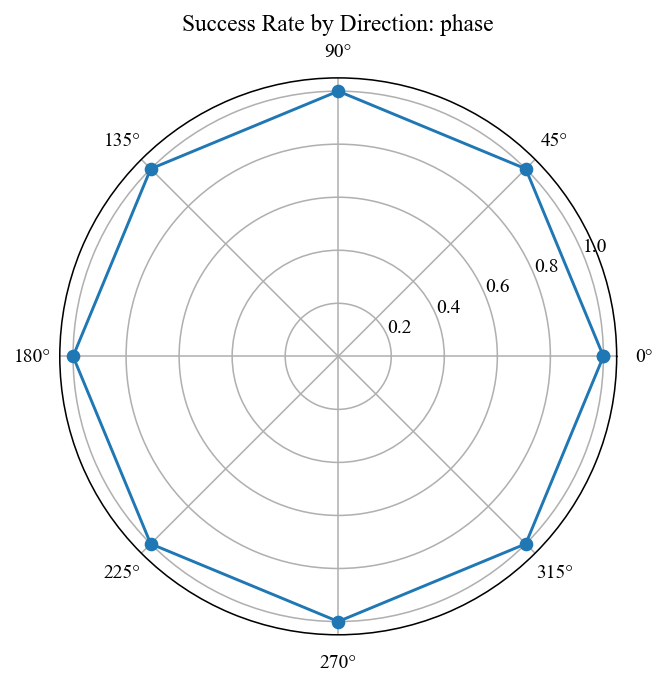

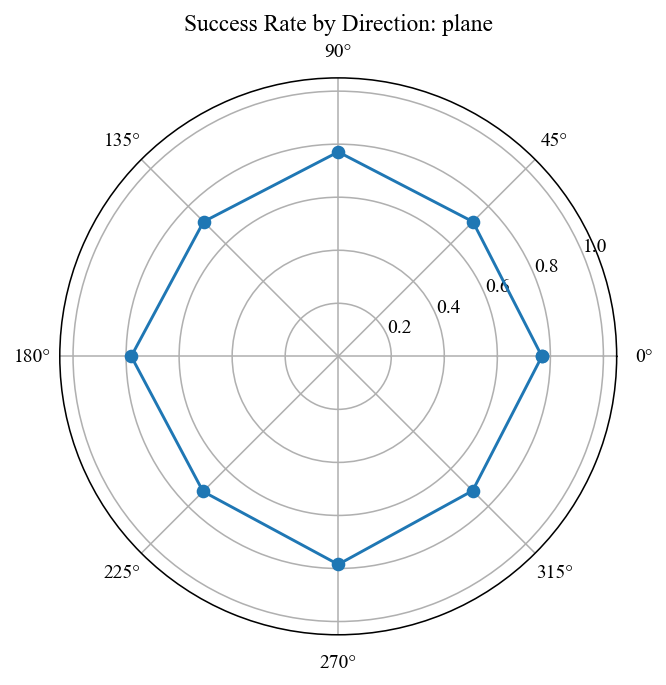

In [46]:
# Plot 10: Polar-ish view of success by direction.
# This is useful to see whether diagonal/horizontal/vertical directions behave differently.

for method in methods:
    g = direction_summary[direction_summary["method"] == method].sort_values("direction_deg")

    theta = np.deg2rad(g["direction_deg"].values)
    r = g["success_0_2"].values

    # Close the curve.
    theta = np.concatenate([theta, theta[:1]])
    r = np.concatenate([r, r[:1]])

    fig = plt.figure(figsize=(5.0, 5.0))
    ax = fig.add_subplot(111, projection="polar")
    ax.plot(theta, r, marker="o")
    ax.set_title(f"Success Rate by Direction: {method}")
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

/var/folders/g2/g88jmmpn74j7j_hr4sgn9zjw0000gr/T/ipykernel_73106/1337330522.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=methods, showfliers=False)


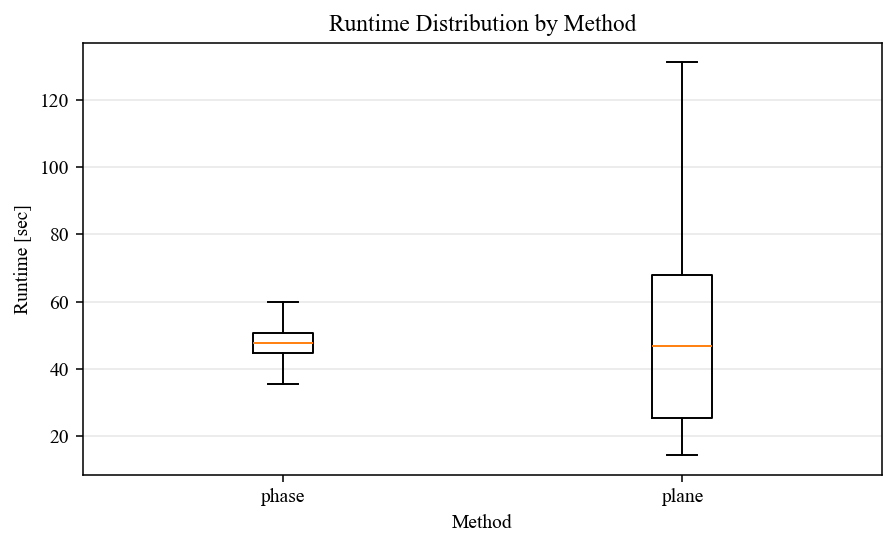

In [47]:
# Plot 11: Runtime comparison.

fig, ax = plt.subplots(figsize=(6.5, 4.0))

values = [df_ok.loc[df_ok["method"] == m, "runtime_sec"].dropna().values for m in methods]

ax.boxplot(values, labels=methods, showfliers=False)
ax.set_title("Runtime Distribution by Method")
ax.set_xlabel("Method")
ax.set_ylabel("Runtime [sec]")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

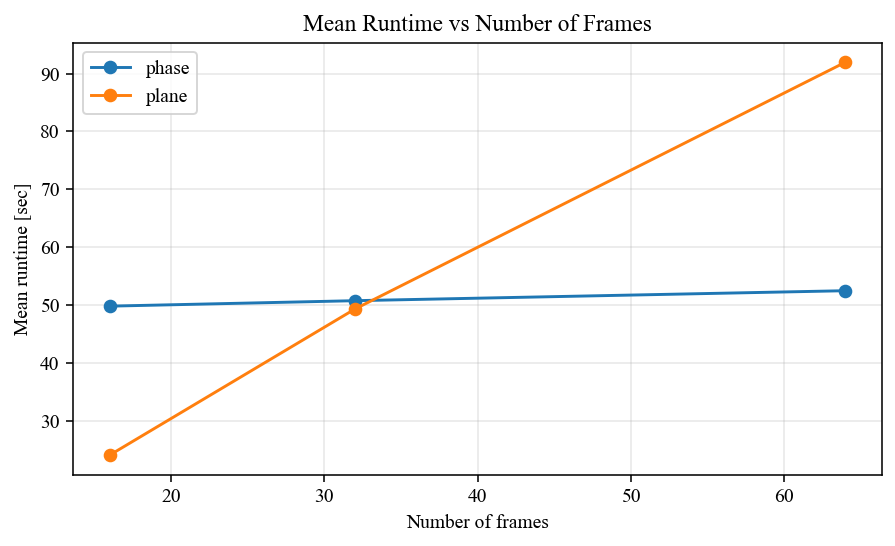

In [48]:
# Plot 12: Runtime vs number of frames.

grouped_lineplot(
    T_summary,
    x="T",
    y="mean_runtime",
    title="Mean Runtime vs Number of Frames",
    xlabel="Number of frames",
    ylabel="Mean runtime [sec]",
)
plt.show()

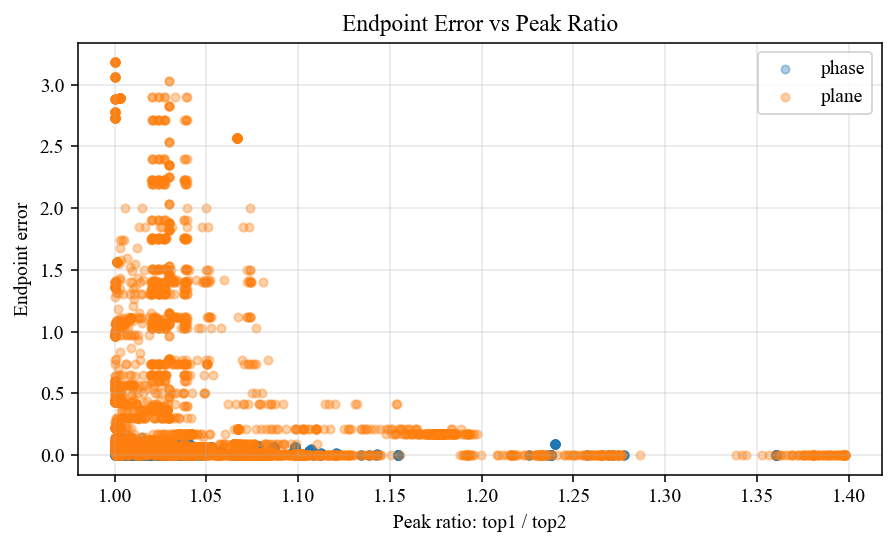

In [49]:
# Plot 13: Endpoint error vs peak ratio.
# This tells you whether score sharpness predicts accuracy.

fig, ax = plt.subplots(figsize=(6.5, 4.0))

for method, g in df_ok.groupby("method"):
    ax.scatter(
        g["peak_ratio"],
        g["endpoint_error"],
        alpha=0.35,
        label=method,
        s=18,
    )

ax.set_title("Endpoint Error vs Peak Ratio")
ax.set_xlabel("Peak ratio: top1 / top2")
ax.set_ylabel("Endpoint error")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

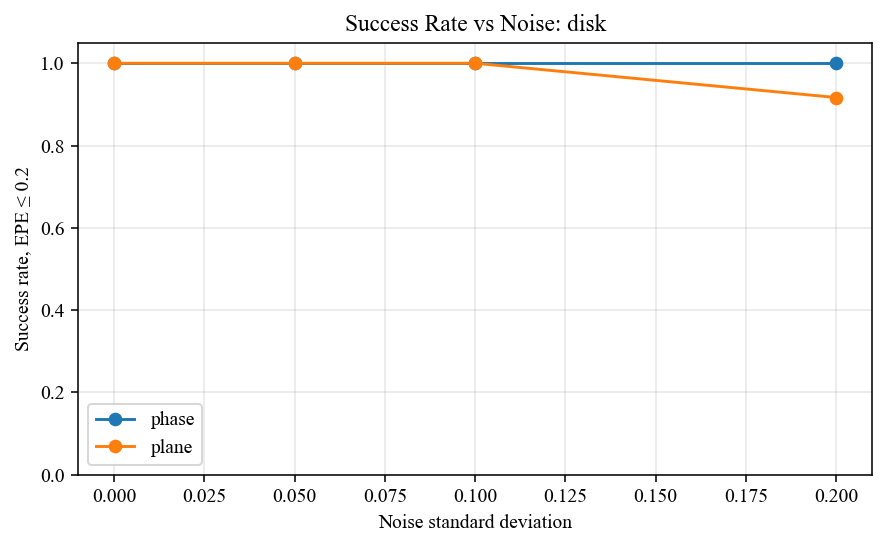

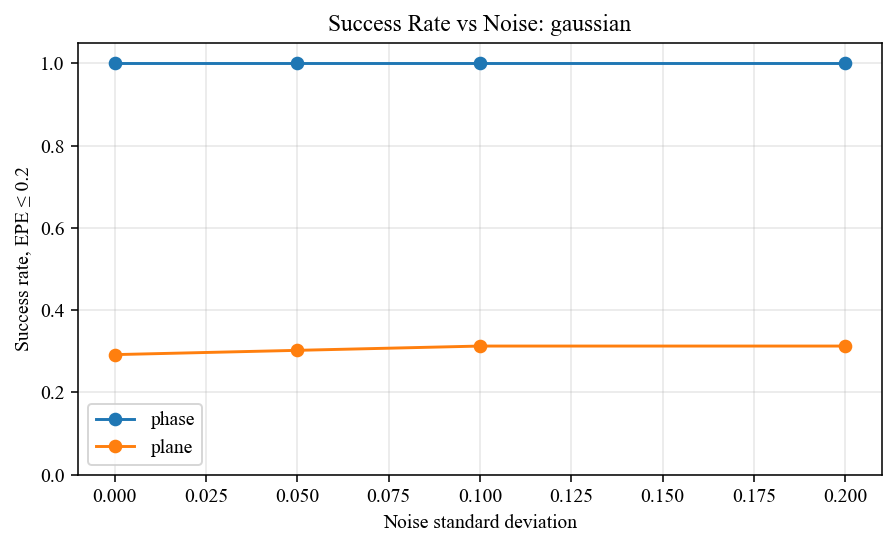

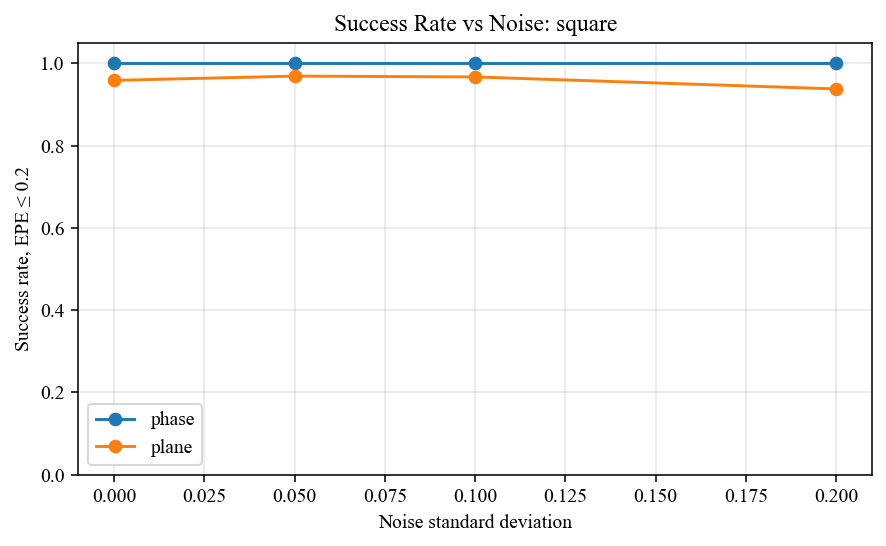

In [50]:
# Plot 15: Shape-specific robustness to noise.

shape_noise_summary = (
    df_ok.groupby(["shape", "method", "noise_std"])
    .agg(
        mean_epe=("endpoint_error", "mean"),
        success_0_2=("success_at_0.2", "mean"),
    )
    .reset_index()
)

for shape in sorted(df_ok["shape"].dropna().unique()):
    g = shape_noise_summary[shape_noise_summary["shape"] == shape]

    grouped_lineplot(
        g,
        x="noise_std",
        y="success_0_2",
        title=f"Success Rate vs Noise: {shape}",
        xlabel="Noise standard deviation",
        ylabel="Success rate, EPE ≤ 0.2",
    )
    plt.ylim(0, 1.05)
    plt.show()

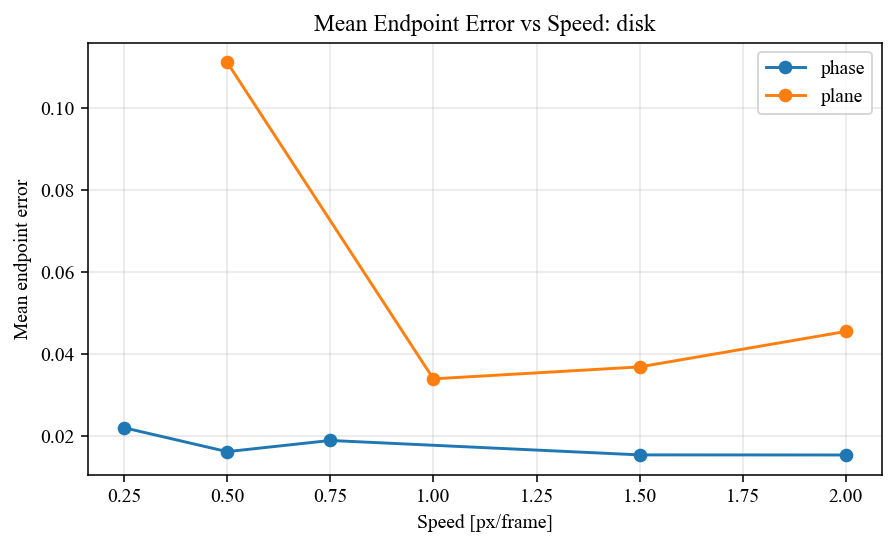

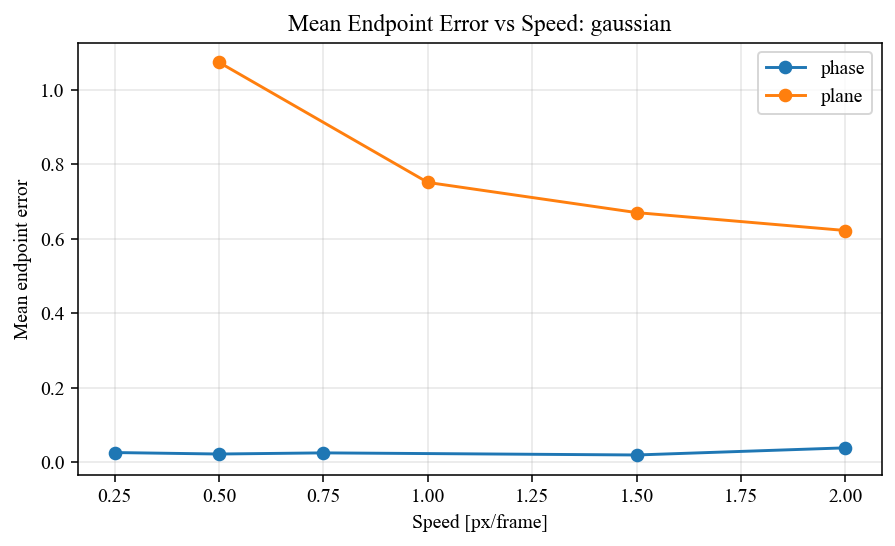

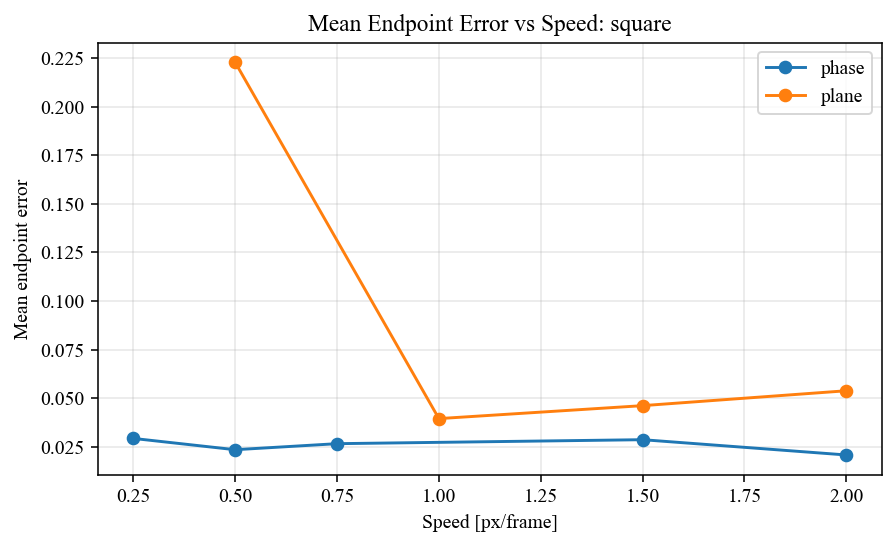

In [51]:
# Plot 16: Shape-specific error vs speed.

shape_speed_summary = (
    df_ok.groupby(["shape", "method", "speed"])
    .agg(
        mean_epe=("endpoint_error", "mean"),
        success_0_2=("success_at_0.2", "mean"),
    )
    .reset_index()
)

for shape in sorted(df_ok["shape"].dropna().unique()):
    g = shape_speed_summary[shape_speed_summary["shape"] == shape]

    grouped_lineplot(
        g,
        x="speed",
        y="mean_epe",
        title=f"Mean Endpoint Error vs Speed: {shape}",
        xlabel="Speed [px/frame]",
        ylabel="Mean endpoint error",
    )
    plt.show()

In [52]:
# Find worst failure cases.

worst = (
    df_ok.sort_values("endpoint_error", ascending=False)
    [
        [
            "method", "shape", "T", "noise_std", "seed", "speed", "direction_deg",
            "vx_gt", "vy_gt", "vx_hat", "vy_hat",
            "endpoint_error", "speed_error", "angular_error_deg",
            "success_at_0.2", "runtime_sec", "peak_ratio", "peak_margin",
        ]
    ]
    .head(30)
)

worst

,method,shape,T,noise_std,seed,speed,direction_deg,vx_gt,vy_gt,vx_hat,vy_hat,endpoint_error,speed_error,angular_error_deg,success_at_0.2,runtime_sec,peak_ratio,peak_margin
5761,plane,gaussian,16.0,0.0,3.0,0.5,0.0,5.000000e-01,0.000000e+00,2.466667,-2.5,3.180845,3.012043,45.384529,False,23.516894,1.000000,0.000183
5756,plane,gaussian,16.0,0.0,2.0,0.5,0.0,5.000000e-01,0.000000e+00,2.466667,-2.5,3.180845,3.012043,45.384529,False,17.901459,1.000000,0.000183
5755,plane,gaussian,16.0,0.0,1.0,0.5,0.0,5.000000e-01,0.000000e+00,2.466667,-2.5,3.180845,3.012043,45.384529,False,18.166160,1.000000,0.000183
5754,plane,gaussian,16.0,0.0,0.0,0.5,0.0,5.000000e-01,0.000000e+00,2.466667,-2.5,3.180845,3.012043,45.384529,False,17.141751,1.000000,0.000183
5763,plane,gaussian,16.0,0.0,4.0,0.5,0.0,5.000000e-01,0.000000e+00,2.466667,-2.5,3.180845,3.012043,45.384529,False,30.883958,1.000000,0.000183
5997,plane,gaussian,16.0,0.0,2.0,0.5,180.0,-5.000000e-01,6.123234e-17,-2.466667,-2.5,3.180845,3.012043,45.384529,False,24.688261,1.000000,0.000305
5995,plane,gaussian,16.0,0.0,0.0,0.5,180.0,-5.000000e-01,6.123234e-17,-2.466667,-2.5,3.180845,3.012043,45.384529,False,25.230443,1.000000,0.000305
5996,plane,gaussian,16.0,0.0,1.0,0.5,180.0,-5.000000e-01,6.123234e-17,-2.466667,-2.5,3.180845,3.012043,45.384529,False,24.878400,1.000000,0.000305
5998,plane,gaussian,16.0,0.0,3.0,0.5,180.0,-5.000000e-01,6.123234e-17,-2.466667,-2.5,3.180845,3.012043,45.384529,False,24.949206,1.000000,0.000305
5999,plane,gaussian,16.0,0.0,4.0,0.5,180.0,-5.000000e-01,6.123234e-17,-2.466667,-2.5,3.180845,3.012043,45.384529,False,24.673767,1.000000,0.000305


In [53]:
# Look at all failures under the EPE <= 0.2 criterion.

fail_02 = df_ok[~df_ok["success_at_0.2"]].copy()

print("num failures:", len(fail_02))
print("failure rate:", len(fail_02) / len(df_ok))

fail_summary = (
    fail_02.groupby(["method", "shape", "T", "noise_std", "speed"])
    .size()
    .reset_index(name="n_failures")
    .sort_values("n_failures", ascending=False)
)

fail_summary.head(30)

num failures: 1456
failure rate: 0.12638888888888888


,method,shape,T,noise_std,speed,n_failures
0,plane,disk,16.0,0.20,0.5,40
33,plane,gaussian,64.0,0.00,0.5,40
31,plane,gaussian,32.0,0.20,1.5,40
29,plane,gaussian,32.0,0.20,0.5,40
35,plane,gaussian,64.0,0.10,0.5,40
27,plane,gaussian,32.0,0.10,1.5,40
25,plane,gaussian,32.0,0.10,0.5,40
36,plane,gaussian,64.0,0.20,0.5,40
23,plane,gaussian,32.0,0.05,1.5,40
22,plane,gaussian,32.0,0.05,1.0,40


In [54]:
# Compare methods pairwise on matched experimental settings.
# This assumes every configuration has both methods.

key_cols = [
    "shape", "size", "T", "H", "W", "noise_std", "seed", "speed", "direction_deg"
]

wide = df_ok.pivot_table(
    index=key_cols,
    columns="method",
    values="endpoint_error",
    aggfunc="mean",
).reset_index()

wide.head()

method,shape,size,T,H,W,noise_std,seed,speed,direction_deg,phase,plane
0,disk,5.0,16.0,128.0,128.0,0.0,0.0,0.25,0.0,0.050000,NaN
1,disk,5.0,16.0,128.0,128.0,0.0,0.0,0.25,45.0,0.014298,NaN
2,disk,5.0,16.0,128.0,128.0,0.0,0.0,0.25,90.0,0.050000,NaN
3,disk,5.0,16.0,128.0,128.0,0.0,0.0,0.25,135.0,0.014298,NaN
4,disk,5.0,16.0,128.0,128.0,0.0,0.0,0.25,180.0,0.050000,NaN


In [55]:
# If methods are named phase and plane, compute where each wins.

if {"phase", "plane"}.issubset(set(df_ok["method"].unique())):
    wide["plane_minus_phase_epe"] = wide["plane"] - wide["phase"]
    wide["winner"] = np.where(
        wide["plane_minus_phase_epe"] < 0,
        "plane",
        np.where(wide["plane_minus_phase_epe"] > 0, "phase", "tie")
    )

    print(wide["winner"].value_counts())

    wide.groupby(["shape", "winner"]).size().reset_index(name="count")

winner
tie      3914
phase    3123
plane     390
Name: count, dtype: int64


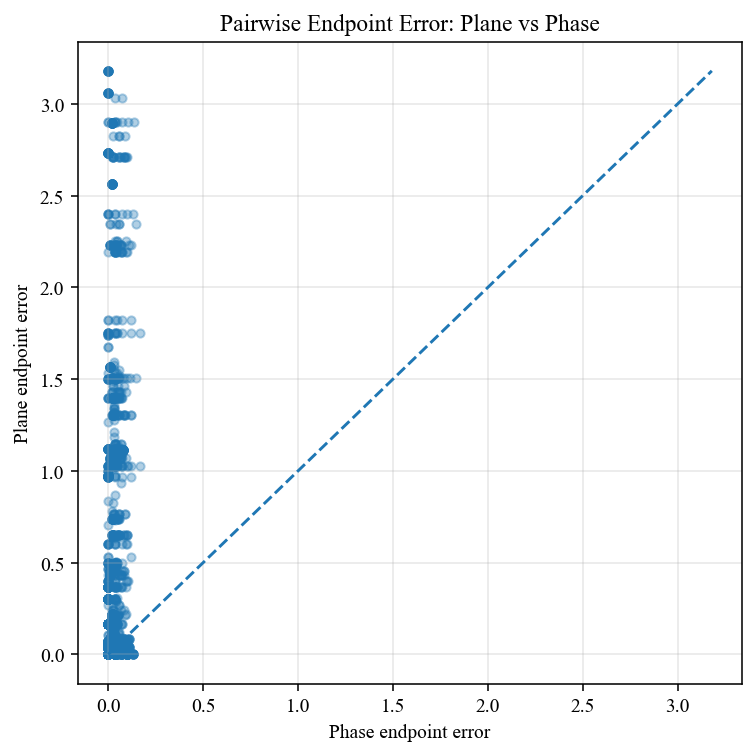

In [56]:
# Plot direct pairwise comparison: each point is one exact test condition.

if {"phase", "plane"}.issubset(set(df_ok["method"].unique())):
    fig, ax = plt.subplots(figsize=(5.5, 5.5))

    ax.scatter(wide["phase"], wide["plane"], alpha=0.35, s=18)

    lim = np.nanmax([wide["phase"].max(), wide["plane"].max()])
    ax.plot([0, lim], [0, lim], linestyle="--")

    ax.set_title("Pairwise Endpoint Error: Plane vs Phase")
    ax.set_xlabel("Phase endpoint error")
    ax.set_ylabel("Plane endpoint error")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

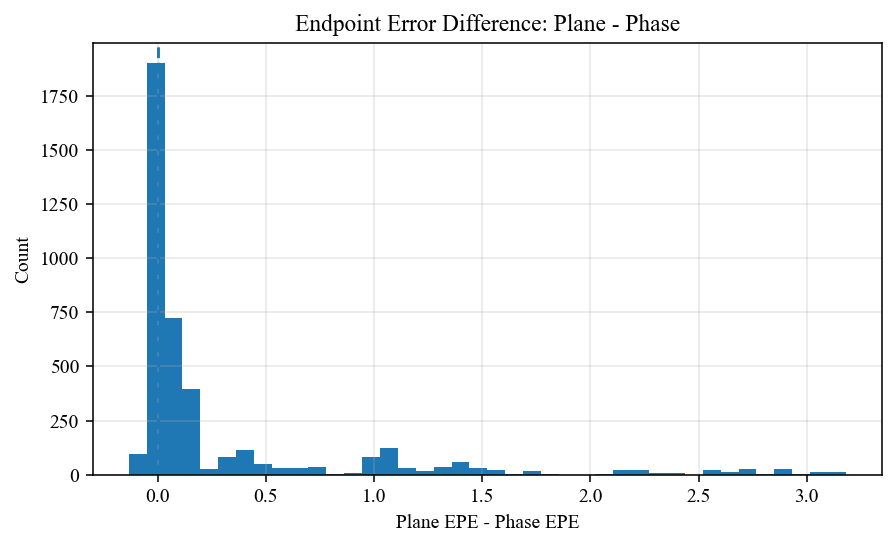

In [57]:
# Difference plot: negative means plane is better.

if {"phase", "plane"}.issubset(set(df_ok["method"].unique())):
    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    ax.hist(wide["plane_minus_phase_epe"].dropna(), bins=40)
    ax.axvline(0, linestyle="--")

    ax.set_title("Endpoint Error Difference: Plane - Phase")
    ax.set_xlabel("Plane EPE - Phase EPE")
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [58]:
# Pairwise win rate by condition.

if {"phase", "plane"}.issubset(set(df_ok["method"].unique())):
    win_by_shape = (
        wide.groupby("shape")
        .agg(
            n=("winner", "count"),
            plane_win_rate=("winner", lambda x: np.mean(x == "plane")),
            phase_win_rate=("winner", lambda x: np.mean(x == "phase")),
            tie_rate=("winner", lambda x: np.mean(x == "tie")),
            mean_plane_minus_phase=("plane_minus_phase_epe", "mean"),
            median_plane_minus_phase=("plane_minus_phase_epe", "median"),
        )
        .reset_index()
    )

    win_by_shape

## Things to look for

The main result is not just which method has the lowest average error. Look for structure:

1. Does one method fail mostly at high speed?
2. Does one method fail mostly at short temporal windows, e.g. T = 16?
3. Does noise hurt one method more than the other?
4. Are square/disk objects harder than Gaussian objects?
5. Does high peak ratio correlate with low endpoint error?
6. Does the plane detector become better as T increases because the Fourier plane becomes sharper?
7. Does the phase method have directional biases?
8. Is one method much slower than the other?

For the final report, the strongest plots are probably:

- success rate vs noise
- success rate vs number of frames
- endpoint error vs speed
- pairwise plane-vs-phase scatter
- runtime comparison
- worst failure cases table